In [1]:
import pandas as pd

train_df = pd.read_csv('/content/train.csv', engine='python', on_bad_lines='skip')
test_df = pd.read_csv('/content/test.csv', engine='python', on_bad_lines='skip')

df = pd.concat([train_df, test_df], ignore_index=True)

In [2]:
df.head()

,Artist,Song,Genre,Language,Lyrics,Song year,Track_id
0,12 stones,world so cold,Rock,en,"It starts with pain, followed by hate\nFueled ...",NaN,NaN
1,12 stones,broken,Rock,en,Freedom!\nAlone again again alone\nPatiently w...,NaN,NaN
2,12 stones,3 leaf loser,Rock,en,"Biting the hand that feeds you, lying to the v...",NaN,NaN
3,12 stones,anthem for the underdog,Rock,en,You say you know just who I am\nBut you can't ...,NaN,NaN
4,12 stones,adrenaline,Rock,en,My heart is beating faster can't control these...,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298118 entries, 0 to 298117
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Artist     298118 non-null  object 
 1   Song       298117 non-null  object 
 2   Genre      298118 non-null  object 
 3   Language   290179 non-null  object 
 4   Lyrics     298083 non-null  object 
 5   Song year  7935 non-null    float64
 6   Track_id   7935 non-null    float64
dtypes: float64(2), object(5)
memory usage: 15.9+ MB


In [4]:
len(df)

298118

In [5]:
df['Genre'].value_counts()

,count
Genre,
Rock,122814
Pop,109824
Metal,21101
Jazz,14205
Folk,9139
Indie,8959
R&B,3303
Hip-Hop,3200
Electronic,2873


<Axes: title={'center': 'Count of Songs by Genre'}, xlabel='Genre', ylabel='Count'>

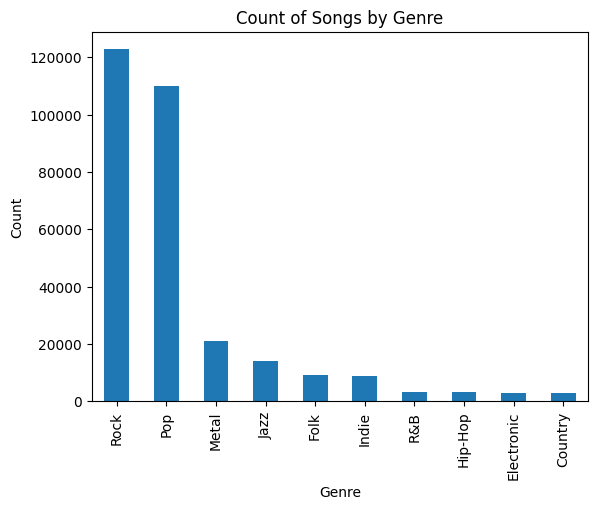

In [6]:
import matplotlib.pyplot as plt

plot = df['Genre'].value_counts().plot(kind='bar')
plot.set_xlabel('Genre')
plot.set_ylabel('Count')
plot.set_title('Count of Songs by Genre')
plot

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import time


# clean to get lyrics without line breaks
df['clean_text'] = df['Lyrics'].str.replace('\n', ' ', regex=False)

# bc title says multilingual, filtering for only english songs
common_english_words = {'the', 'is', 'and', 'to', 'a', 'in', 'that', 'it'}
def is_likely_english(text):
    if not isinstance(text, str): return False
    words = set(text.lower().split())
    return len(words.intersection(common_english_words)) >= 2

df_english = df[df['clean_text'].apply(is_likely_english)].copy()
print(f" english songs: {len(df_english)}")


# vectorize songs on clean lyrics
vectorizer = TfidfVectorizer(max_features=4000, stop_words='english')
X = vectorizer.fit_transform(df_english['clean_text']).toarray()

# set up machine learning step
# encode targets, and create train/test split
encoder = LabelEncoder()
y_integers = encoder.fit_transform(df_english['Genre'])

X_train, X_test, y_train_labels, y_test_labels = train_test_split(X, y_integers, test_size=0.2, random_state=42)

# OHE for NN
y_train = to_categorical(y_train_labels)
y_test = to_categorical(y_test_labels)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_train_labels: {y_train_labels.shape}")

 english songs: 259190
X_train: (207352, 4000)
y_train: (207352, 10)
y_train_labels: (207352,)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score
import time

# simple NN use Gemini to set params

print("Starting training")
start_train = time.time()

model = Sequential()
model.add(Dense(64, input_dim=4000, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(X_test, y_test))

end_train = time.time()
training_duration_nn = end_train - start_train

print("Starting inference")
start_infer = time.time()

_, accuracy = model.evaluate(X_test, y_test)
print(f"\nFinal Accuracy: {accuracy*100:.2f}%")

end_infer = time.time()
total_inference_time_nn = end_infer - start_infer

# Calculate time per sample
num_samples = len(X_test)
time_per_sample = total_inference_time_nn / num_samples

print(f"Training time taken NN: {training_duration_nn:.4f} seconds")
print(f"Total Inference Time NN: {total_inference_time_nn:.4f} seconds")
print(f"Inference Time Per Sample NN: {time_per_sample:.6f} seconds")
print(f"Inference Time Per Sample NN: {time_per_sample * 1000:.4f} ms")

Starting training


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
6480/6480 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - accuracy: 0.5319 - loss: 1.3751 - val_accuracy: 0.6004 - val_loss: 1.1586
Epoch 2/10
6480/6480 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.6037 - loss: 1.1654 - val_accuracy: 0.6094 - val_loss: 1.1339
Epoch 3/10
6480/6480 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.6238 - loss: 1.1087 - val_accuracy: 0.6169 - val_loss: 1.1231
Epoch 4/10
6480/6480 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.6398 - loss: 1.0666 - val_accuracy: 0.6212 - val_loss: 1.1176
Epoch 5/10
6480/6480 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.6532 - loss: 1.0317 - val_accuracy: 0.6276 - val_loss: 1.1144
Epoch 6/10
6480/6480 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.6671 - loss: 1.0002 - val_accuracy: 0.6293 - val_loss: 1.1152
Epoch 7/10
6480/6480 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.6783 - loss: 0.9736 - val_accuracy: 0.6293 - val_loss: 1.1213
Epoch 8/10
6480/6480 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.6856 - loss: 0

1620/1620 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


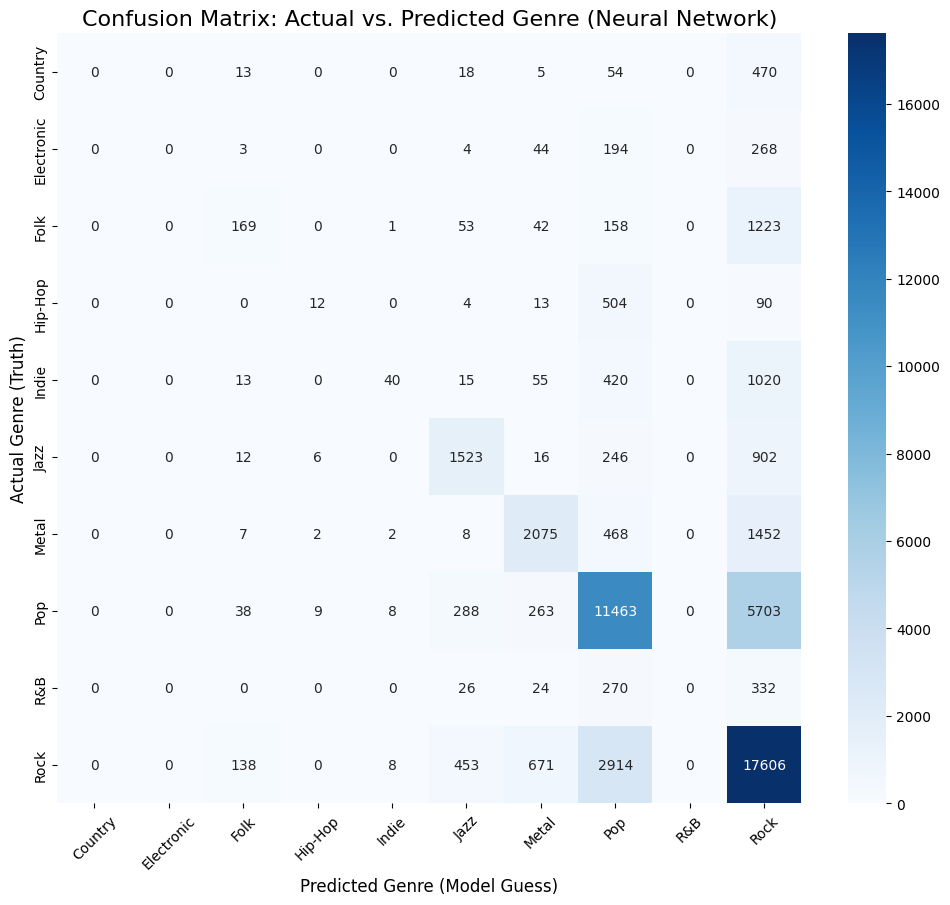

              precision    recall  f1-score   support

     Country       0.00      0.00      0.00       560
  Electronic       0.00      0.00      0.00       513
        Folk       0.43      0.10      0.17      1646
     Hip-Hop       0.41      0.02      0.04       623
       Indie       0.68      0.03      0.05      1563
        Jazz       0.64      0.56      0.60      2705
       Metal       0.65      0.52      0.57      4014
         Pop       0.69      0.65      0.67     17772
         R&B       0.00      0.00      0.00       652
        Rock       0.61      0.81      0.69     21790

    accuracy                           0.63     51838
   macro avg       0.41      0.27      0.28     51838
weighted avg       0.61      0.63      0.60     51838



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

#getting predictions
predictions_proba = model.predict(X_test)
predictions_labels = np.argmax(predictions_proba, axis=1)

# confusion matrix for each genre, predicted vs actual
cm = confusion_matrix(y_test_labels, predictions_labels)

# decode
genre_labels = encoder.classes_


# plotting heat map
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=genre_labels, yticklabels=genre_labels)

plt.title('Confusion Matrix: Actual vs. Predicted Genre (Neural Network)', fontsize=16)
plt.ylabel('Actual Genre (Truth)', fontsize=12)
plt.xlabel('Predicted Genre (Model Guess)', fontsize=12)
plt.xticks(rotation=45)
plt.show()


report_dict = classification_report(y_test_labels, predictions_labels, target_names=genre_labels, output_dict=True)
print(classification_report(y_test_labels, predictions_labels, target_names=genre_labels))

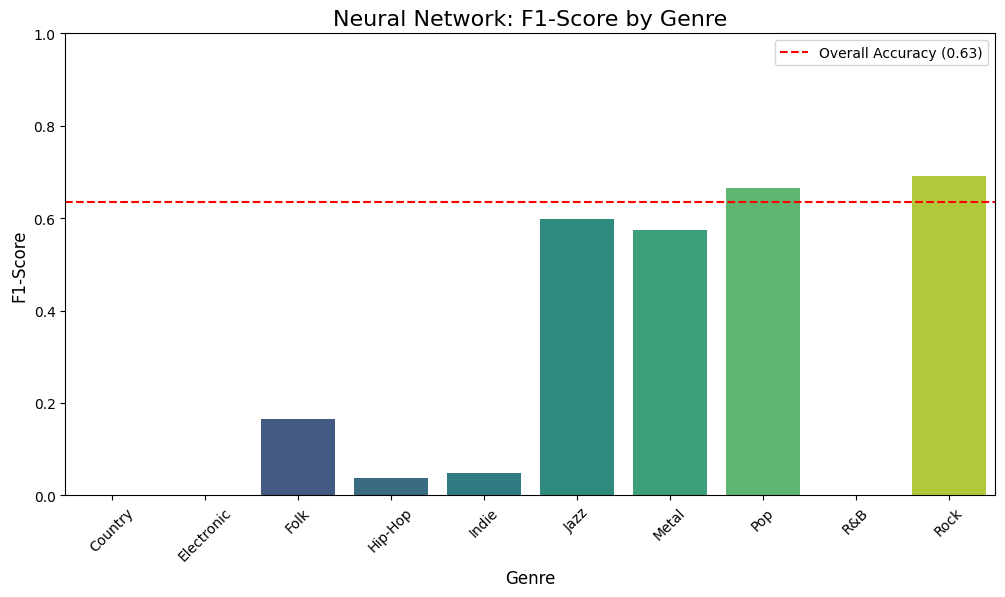


DETAILED neural network
              precision    recall  f1-score   support

     Country       0.00      0.00      0.00       560
  Electronic       0.00      0.00      0.00       513
        Folk       0.43      0.10      0.17      1646
     Hip-Hop       0.41      0.02      0.04       623
       Indie       0.68      0.03      0.05      1563
        Jazz       0.64      0.56      0.60      2705
       Metal       0.65      0.52      0.57      4014
         Pop       0.69      0.65      0.67     17772
         R&B       0.00      0.00      0.00       652
        Rock       0.61      0.81      0.69     21790

    accuracy                           0.63     51838
   macro avg       0.41      0.27      0.28     51838
weighted avg       0.61      0.63      0.60     51838



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:

# Convert to a clean df
# visualize f1 scores

f1_data = []
for genre in encoder.classes_:
    score = report_dict[genre]['f1-score']
    f1_data.append({'Genre': genre, 'F1-Score': score})

df_f1 = pd.DataFrame(f1_data)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_f1, x='Genre', y='F1-Score', hue='Genre', palette='viridis', legend=False)
overall_acc = report_dict['accuracy']
plt.axhline(overall_acc, color='red', linestyle='--', label=f'Overall Accuracy ({overall_acc:.2f})')

plt.title('Neural Network: F1-Score by Genre', fontsize=16)
plt.ylabel('F1-Score', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.show()

# also print the detailed info
print("\n" + "="*60)
print("DETAILED neural network")
print("="*60)
print(classification_report(y_test_labels, predictions_labels, target_names=encoder.classes_))

In [14]:
import numpy as np

# Use for  Naive Bayes

y_train_labels = np.argmax(y_train, axis=1)
y_test_labels = np.argmax(y_test, axis=1)


In [16]:
from sklearn.naive_bayes import MultinomialNB
import time
from sklearn.metrics import accuracy_score
# NB

nb_model = MultinomialNB()

print("Start training")
start_train = time.time()

nb_model.fit(X_train, y_train_labels)

end_train = time.time()
training_duration_NB = end_train - start_train
print(f"Training time taken NB: {training_duration_NB:.4f} seconds")

print("Starting inference")
start_infer = time.time()

nb_predictions = nb_model.predict(X_test)
nb_acc = accuracy_score(y_test_labels, nb_predictions)
print(f"Naive Bayes Accuracy: {nb_acc*100:.2f}%")

end_infer = time.time()
total_inference_time_nb = end_infer - start_infer

num_samples = len(X_test)
time_per_sample_nb = total_inference_time_nb / num_samples

print(f"Total Inference Time NB: {total_inference_time_nb:.4f} seconds")
print(f"Inference Time Per Sample NB: {time_per_sample_nb:.6f} seconds")
print(f"Inference Time Per Sample NB: {time_per_sample_nb * 1000:.4f} ms")

Start training
Training time taken NB: 1.4329 seconds
Starting inference
Naive Bayes Accuracy: 55.58%
Total Inference Time NB: 0.2330 seconds
Inference Time Per Sample NB: 0.000004 seconds
Inference Time Per Sample NB: 0.0045 ms


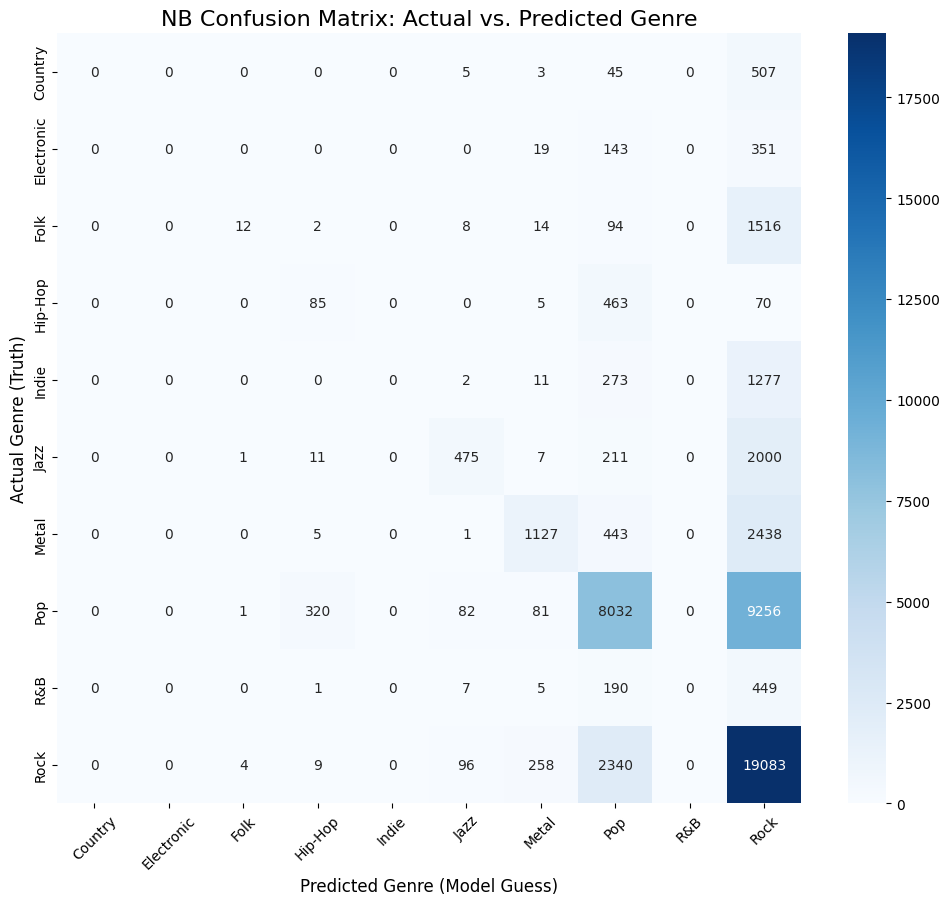

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# calculate confusion matrix
cm = confusion_matrix(y_test_labels, nb_predictions)
genre_labels = encoder.classes_


# heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=genre_labels, yticklabels=genre_labels)

plt.title('NB Confusion Matrix: Actual vs. Predicted Genre', fontsize=16)
plt.ylabel('Actual Genre (Truth)', fontsize=12)
plt.xlabel('Predicted Genre (Model Guess)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [18]:
# detailed look at NB

from sklearn.metrics import confusion_matrix, classification_report

report_dict = classification_report(y_test_labels, nb_predictions, target_names=genre_labels, output_dict=True)
print("NB detailed info")
print(classification_report(y_test_labels, nb_predictions, target_names=genre_labels))


NB detailed info
              precision    recall  f1-score   support

     Country       0.00      0.00      0.00       560
  Electronic       0.00      0.00      0.00       513
        Folk       0.67      0.01      0.01      1646
     Hip-Hop       0.20      0.14      0.16       623
       Indie       0.00      0.00      0.00      1563
        Jazz       0.70      0.18      0.28      2705
       Metal       0.74      0.28      0.41      4014
         Pop       0.66      0.45      0.54     17772
         R&B       0.00      0.00      0.00       652
        Rock       0.52      0.88      0.65     21790

    accuracy                           0.56     51838
   macro avg       0.35      0.19      0.20     51838
weighted avg       0.56      0.56      0.51     51838



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

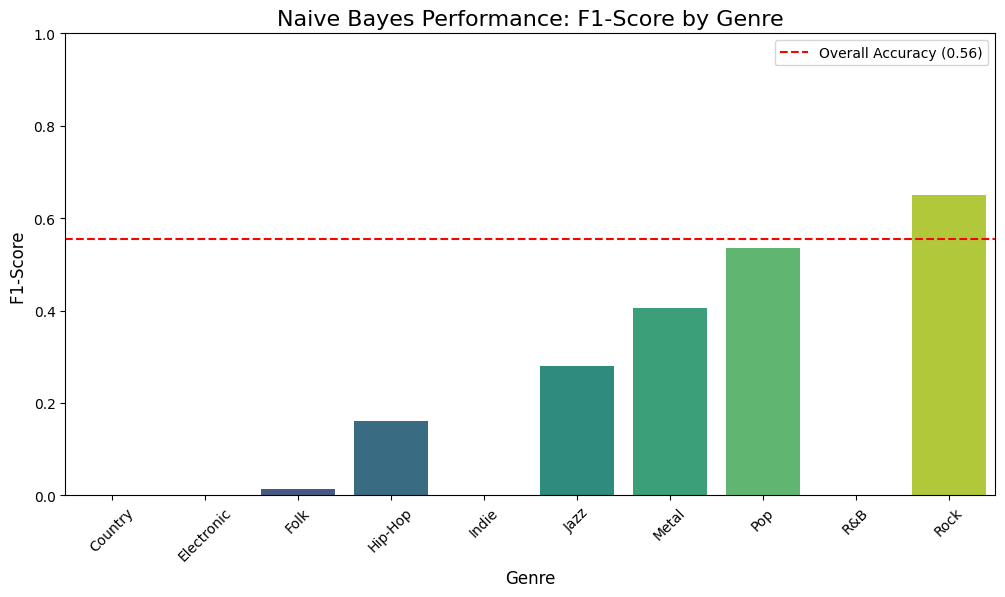

In [19]:
# same cell for f1 but for NB

f1_data = []
for genre in encoder.classes_:
    score = report_dict[genre]['f1-score']
    f1_data.append({'Genre': genre, 'F1-Score': score})

df_f1 = pd.DataFrame(f1_data)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_f1, x='Genre', y='F1-Score', hue='Genre', palette='viridis', legend=False)
overall_acc = report_dict['accuracy']
plt.axhline(overall_acc, color='red', linestyle='--', label=f'Overall Accuracy ({overall_acc:.2f})')

plt.title('Naive Bayes Performance: F1-Score by Genre', fontsize=16)
plt.ylabel('F1-Score ', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Random Forest using sklearn
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Start training")
start_train = time.time()

rf_model.fit(X_train, y_train_labels)

end_train = time.time()
training_duration_RF = end_train - start_train
print(f"Training time taken RF: {training_duration_RF:.4f} seconds")

print("Start inference")
start_infer = time.time()

rf_predictions = rf_model.predict(X_test)

end_infer = time.time()
total_inference_time_rf = end_infer - start_infer

rf_acc = accuracy_score(y_test_labels, rf_predictions)
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")


num_samples = len(X_test)
time_per_sample_rf = total_inference_time_rf / num_samples

print(f"Total Inference Time: {total_inference_time_rf:.4f} seconds")
print(f"Inference Time Per Sample: {time_per_sample_rf:.6f} seconds")

Start training
Training time taken RF: 719.2038 seconds
Start inference
Random Forest Accuracy: 66.70%
Total Inference Time: 7.3012 seconds
Inference Time Per Sample: 0.000141 seconds


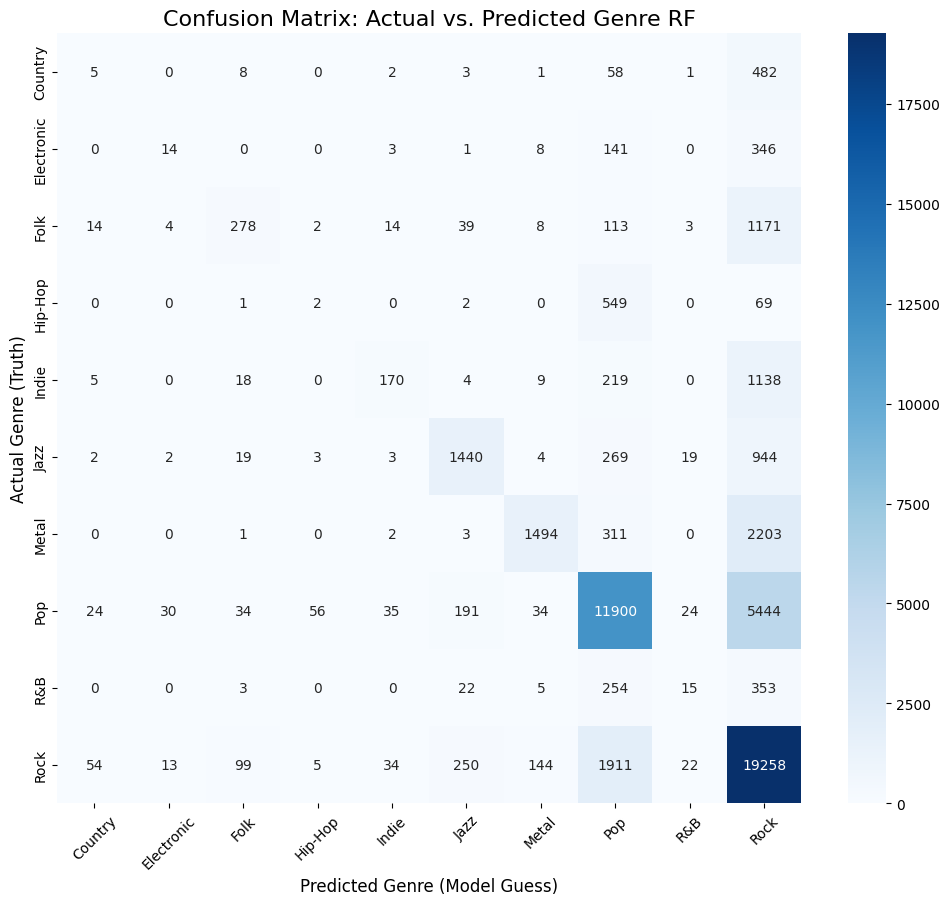

              precision    recall  f1-score   support

     Country       0.05      0.01      0.02       560
  Electronic       0.22      0.03      0.05       513
        Folk       0.60      0.17      0.26      1646
     Hip-Hop       0.03      0.00      0.01       623
       Indie       0.65      0.11      0.19      1563
        Jazz       0.74      0.53      0.62      2705
       Metal       0.88      0.37      0.52      4014
         Pop       0.76      0.67      0.71     17772
         R&B       0.18      0.02      0.04       652
        Rock       0.61      0.88      0.72     21790

    accuracy                           0.67     51838
   macro avg       0.47      0.28      0.31     51838
weighted avg       0.67      0.67      0.64     51838



In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# visualizing and analyzing RF using same code as before
cm = confusion_matrix(y_test_labels, rf_predictions)
genre_labels = encoder.classes_


plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=genre_labels, yticklabels=genre_labels)

plt.title('Confusion Matrix: Actual vs. Predicted Genre RF', fontsize=16)
plt.ylabel('Actual Genre (Truth)', fontsize=12)
plt.xlabel('Predicted Genre (Model Guess)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# info for RF
from sklearn.metrics import confusion_matrix, classification_report

report_dict = classification_report(y_test_labels, rf_predictions, target_names=genre_labels, output_dict=True)
print(classification_report(y_test_labels, rf_predictions, target_names=genre_labels))

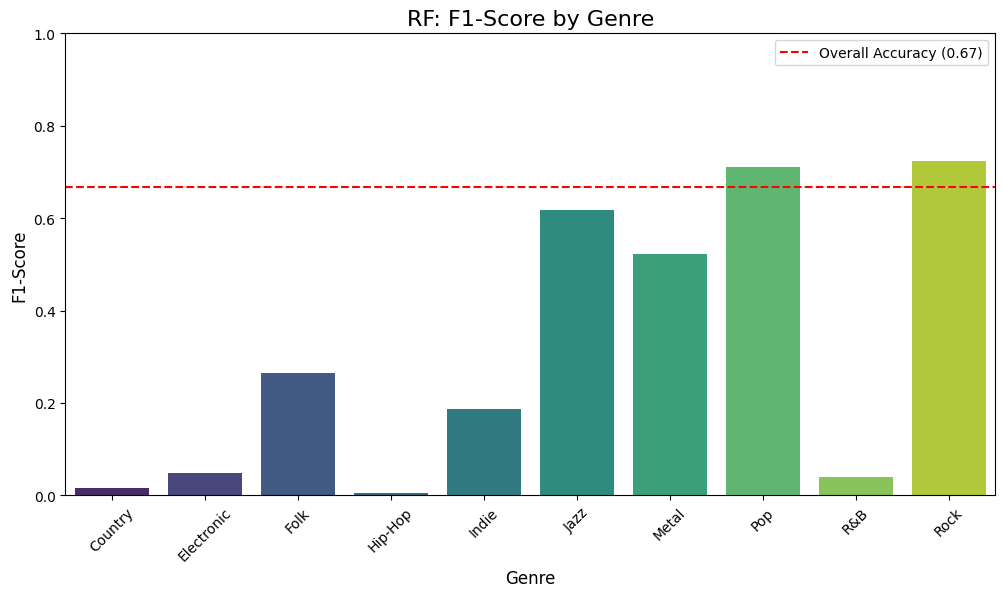


DETAILED RF
              precision    recall  f1-score   support

     Country       0.05      0.01      0.02       560
  Electronic       0.22      0.03      0.05       513
        Folk       0.60      0.17      0.26      1646
     Hip-Hop       0.03      0.00      0.01       623
       Indie       0.65      0.11      0.19      1563
        Jazz       0.74      0.53      0.62      2705
       Metal       0.88      0.37      0.52      4014
         Pop       0.76      0.67      0.71     17772
         R&B       0.18      0.02      0.04       652
        Rock       0.61      0.88      0.72     21790

    accuracy                           0.67     51838
   macro avg       0.47      0.28      0.31     51838
weighted avg       0.67      0.67      0.64     51838



In [ ]:
# duplicate cell for RF
f1_data = []
for genre in encoder.classes_:
    score = report_dict[genre]['f1-score']
    f1_data.append({'Genre': genre, 'F1-Score': score})

df_f1 = pd.DataFrame(f1_data)
plt.figure(figsize=(12, 6))


sns.barplot(data=df_f1, x='Genre', y='F1-Score', hue='Genre', palette='viridis', legend=False)
overall_acc = report_dict['accuracy']
plt.axhline(overall_acc, color='red', linestyle='--', label=f'Overall Accuracy ({overall_acc:.2f})')

plt.title('RF: F1-Score by Genre', fontsize=16)
plt.ylabel('F1-Score', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.show()

print("\n" + "="*60)
print("DETAILED RF")
print("="*60)
print(classification_report(y_test_labels, rf_predictions, target_names=encoder.classes_))

Goals:

C-range Goals
Successfully import dataset, clean, and perform initial analysis to understand dataset
Implement TD-IDF to vectorize lyrics
Implement algorithm with basic accuracy after splitting into training and test tests

B-range Goals
Achieve a high standard of accuracy from our model
Possibly compare performance of model to other algorithms
Meet requirements for poster and demo

Achieve a full-functioning and highly accurate machine learning model


Analysis of Goals: C - all met - dataset imported, cleaned, and analyzed. Implemented TF-IDF and split into training/test with accuracy

B: Given the difficulty of creating an accurate model for lyrics-only classification, we fulfilled these goals. We also were able to compare performance for 3 different models

A. Mostly reached. All models were fully functional and two out of three gave good accuracy based on context of research

In [21]:
!pip install nbconvert

In [ ]:
!jupyter nbconvert --to HTML "/lab04_notebook_meyer_lily.ipynb"